<a href="https://colab.research.google.com/github/AlphaSimpli/ML_project/blob/main/ML_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **1** - Importation des **librairies**

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

## **2** - Chargement des **données**

In [ ]:
import kagglehub, os

path = kagglehub.dataset_download("uciml/sms-spam-collection-dataset")

file_path = path + "/spam.csv"
df = pd.read_csv(file_path, encoding="latin-1")

df = df[['v1','v2']]
df.columns = ['label','message']
df['label'] = df['label'].map({'ham':0, 'spam':1})

df.head()

Using Colab cache for faster access to the 'sms-spam-collection-dataset' dataset.


,label,message
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [ ]:
# ================================
# ADD SYNTHETIC SPAM (DATA AUGMENTATION)
# ================================

extra_spam = [
"You have won the lottery! Send bank details now",
"Claim your lottery winnings immediately",
"You received an inheritance of $2 million",
"Send your bank info to receive your funds",
"Congratulations, you won cash prize",
"Act now to receive money transfer",
"You have pending payment waiting",
"Your PayPal account received money",
"Unclaimed funds available for you",
"Wire transfer ready for pickup",
"URGENT! Verify your bank account now",
"Your account will be closed unless you confirm details",
"Security alert! Login immediately",
"Suspicious activity detected. Verify now",
"Click here to unlock your account",
"You have a new reward waiting",
"Claim your free gift card today",
"Free iPhone waiting for you",
"Limited time offer! Act now",
"You qualify for a loan instantly",
"Earn money fast from home",
"Investment opportunity guaranteed profit",
"Crypto giveaway! Send 1 BTC get 2 BTC",
"You have a package waiting, confirm address",
"Delivery failed. Update your shipping info",
"Final notice: unpaid invoice",
"Your tax refund is ready",
"Government grant approved",
"Winner! Claim your reward now"
]

import pandas as pd

extra_df = pd.DataFrame({
    "label": [1] * len(extra_spam),   # 1 = spam
    "message": extra_spam
})

df = pd.concat([df, extra_df], ignore_index=True)

print("New dataset size:", df.shape)
df['label'].value_counts()

New dataset size: (5601, 2)


,count
label,
0,4825
1,776


# **3** - Exploration des données (EDA)

In [ ]:
print(df.shape)
print(df['label'].value_counts())

(5601, 2)
label
0    4825
1     776
Name: count, dtype: int64


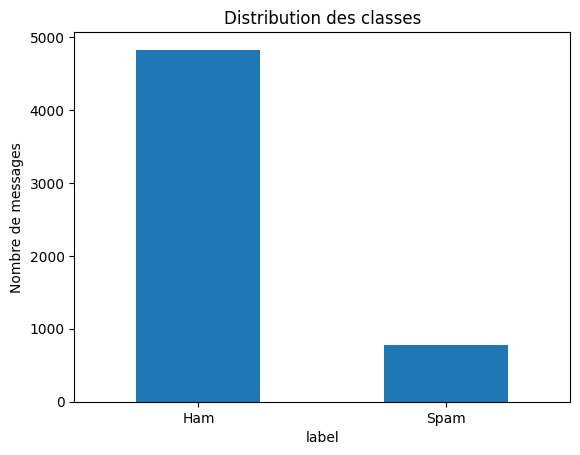

In [ ]:
import matplotlib.pyplot as plt

df['label'].value_counts().plot(kind='bar')
plt.title("Distribution des classes")
plt.xticks([0,1], ['Ham','Spam'], rotation=0)
plt.ylabel("Nombre de messages")
plt.show()

In [ ]:
df['message_length'] = df['message'].apply(len)
df.head()

,label,message,message_length
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,0,U dun say so early hor... U c already then say...,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61


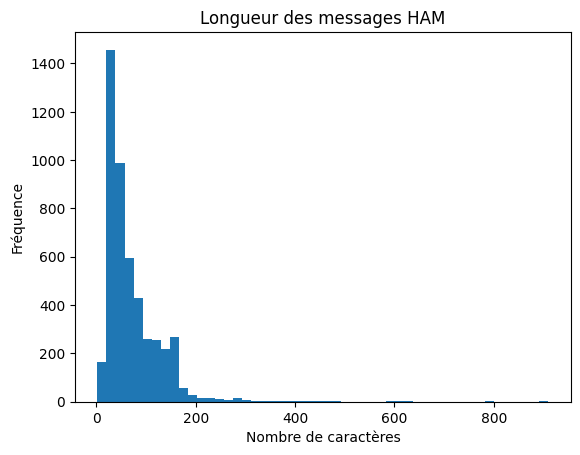

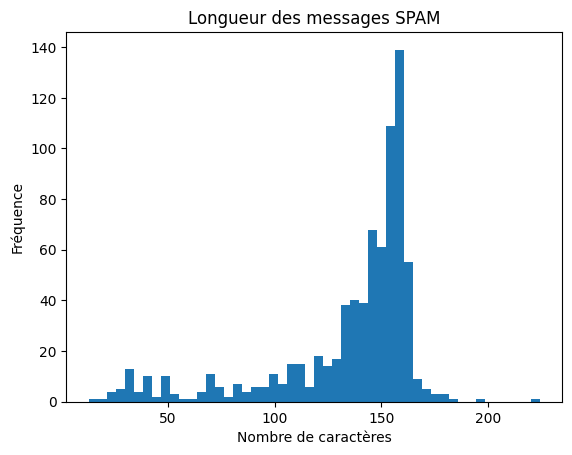

In [ ]:
plt.hist(df[df['label']==0]['message_length'], bins=50)
plt.title("Longueur des messages HAM")
plt.xlabel("Nombre de caractères")
plt.ylabel("Fréquence")
plt.show()

plt.hist(df[df['label']==1]['message_length'], bins=50)
plt.title("Longueur des messages SPAM")
plt.xlabel("Nombre de caractères")
plt.ylabel("Fréquence")
plt.show()

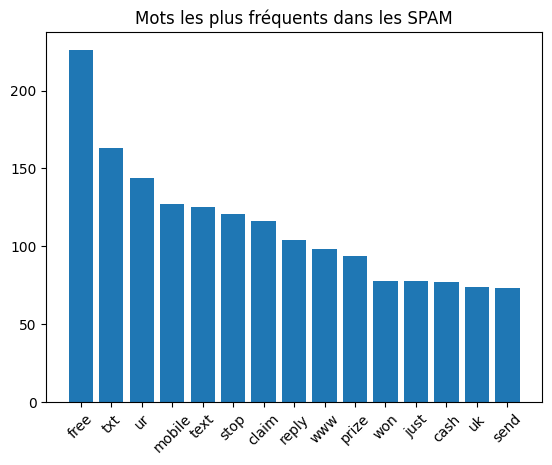

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

spam_words = df[df['label']==1]['message']
vectorizer_words = CountVectorizer(stop_words='english')
X_words = vectorizer_words.fit_transform(spam_words)

word_freq = np.asarray(X_words.sum(axis=0)).ravel()
words = vectorizer_words.get_feature_names_out()

freq_df = pd.DataFrame({'word': words, 'freq': word_freq})
top_words = freq_df.sort_values(by='freq', ascending=False).head(15)

plt.bar(top_words['word'], top_words['freq'])
plt.xticks(rotation=45)
plt.title("Mots les plus fréquents dans les SPAM")
plt.show()

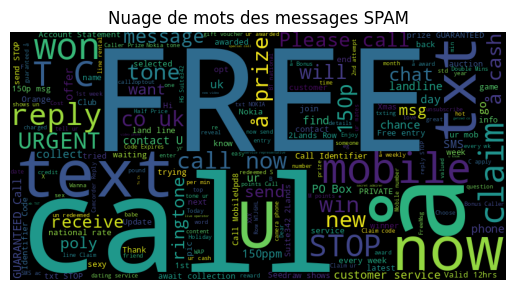

In [ ]:
from wordcloud import WordCloud

spam_text = " ".join(df[df['label']==1]['message'])

wordcloud = WordCloud(width=800, height=400).generate(spam_text)

plt.imshow(wordcloud)
plt.axis("off")
plt.title("Nuage de mots des messages SPAM")
plt.show()

# **3) a** - preprocessing

In [ ]:
import nltk
nltk.download('stopwords')
nltk.download('punkt')
import re
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


In [ ]:
def preprocess_text(text):

    # 1. minuscules
    text = text.lower()

    # 2. supprimer urls
    text = re.sub(r'http\S+', '', text)

    # 3. supprimer nombres
    text = re.sub(r'\d+', '', text)

    # 4. supprimer ponctuation
    text = re.sub(r'[^\w\s]', '', text)

    # 5. tokenisation (split mots)
    words = text.split()

    # 6. supprimer stopwords
    words = [w for w in words if w not in stop_words]

    # 7. stemming (win, winning → win)
    words = [stemmer.stem(w) for w in words]

    return " ".join(words)

In [ ]:
df['clean_message'] = df['message'].apply(preprocess_text)
df[['message','clean_message']].head()

,message,clean_message
0,"Go until jurong point, crazy.. Available only ...",go jurong point crazi avail bugi n great world...
1,Ok lar... Joking wif u oni...,ok lar joke wif u oni
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entri wkli comp win fa cup final tkt st m...
3,U dun say so early hor... U c already then say...,u dun say earli hor u c alreadi say
4,"Nah I don't think he goes to usf, he lives aro...",nah dont think goe usf live around though


# **4** - Train / Test split

In [ ]:
X = df['clean_message']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# **5** - Text → Numbers (TF-IDF)

In [ ]:
vectorizer = TfidfVectorizer(max_features=5000)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print(X_train_tfidf.shape)

(4480, 5000)


In [ ]:
from imblearn.over_sampling import RandomOverSampler

ros = RandomOverSampler(random_state=42)
X_resampled, y_resampled = ros.fit_resample(X_train_tfidf, y_train)


In [ ]:
nb_model = MultinomialNB()
lr_model = LogisticRegression(class_weight='balanced')
mlp_model = MLPClassifier(hidden_layer_sizes=(128,64), max_iter=10)

nb_model.fit(X_resampled, y_resampled)
lr_model.fit(X_resampled, y_resampled)
mlp_model.fit(X_resampled, y_resampled)

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (10) reached and the optimization hasn't converged yet.
  warnings.warn(


MLPClassifier(hidden_layer_sizes=(128, 64), max_iter=10)

# **6️** - Helper function to evaluate models

In [ ]:
def evaluate_model(model, X_test, y_test, name):
    y_pred = model.predict(X_test)

    print("-----", name, "-----")
    print("Accuracy :", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall   :", recall_score(y_test, y_pred))
    print("F1-score :", f1_score(y_test, y_pred))
    print("\nClassification Report:\n")
    print(classification_report(y_test, y_pred))

# **7** - Model 1 — Naive Bayes

In [ ]:
nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)

evaluate_model(nb_model, X_test_tfidf, y_test, "Naive Bayes")

----- Naive Bayes -----
Accuracy : 0.9607493309545049
Precision: 1.0
Recall   : 0.7541899441340782
F1-score : 0.8598726114649682

Classification Report:

              precision    recall  f1-score   support

           0       0.96      1.00      0.98       942
           1       1.00      0.75      0.86       179

    accuracy                           0.96      1121
   macro avg       0.98      0.88      0.92      1121
weighted avg       0.96      0.96      0.96      1121



# **8** - Model 2 — Logistic Regression

In [ ]:
lr_model = LogisticRegression(class_weight='balanced')
lr_model.fit(X_train_tfidf, y_train)

evaluate_model(lr_model, X_test_tfidf, y_test, "Logistic Regression")

----- Logistic Regression -----
Accuracy : 0.9732381801962533
Precision: 0.9257142857142857
Recall   : 0.9050279329608939
F1-score : 0.9152542372881356

Classification Report:

              precision    recall  f1-score   support

           0       0.98      0.99      0.98       942
           1       0.93      0.91      0.92       179

    accuracy                           0.97      1121
   macro avg       0.95      0.95      0.95      1121
weighted avg       0.97      0.97      0.97      1121



# **9** - Model 3 — Neural Network (MLP)

In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weights = dict(enumerate(class_weights))

mlp_model = MLPClassifier(hidden_layer_sizes=(128,64), max_iter=10)
mlp_model.fit(X_train_tfidf, y_train)

evaluate_model(mlp_model, X_test_tfidf, y_test, "Neural Network (MLP)")

----- Neural Network (MLP) -----
Accuracy : 0.9776984834968778
Precision: 0.98125
Recall   : 0.8770949720670391
F1-score : 0.9262536873156342

Classification Report:

              precision    recall  f1-score   support

           0       0.98      1.00      0.99       942
           1       0.98      0.88      0.93       179

    accuracy                           0.98      1121
   macro avg       0.98      0.94      0.96      1121
weighted avg       0.98      0.98      0.98      1121



/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (10) reached and the optimization hasn't converged yet.
  warnings.warn(


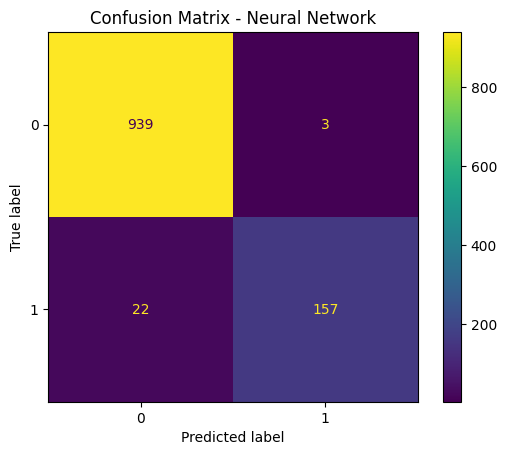

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred = mlp_model.predict(X_test_tfidf)
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix - Neural Network")
plt.show()

# **10** - Compare results in a table

In [ ]:
models = {
    "Naive Bayes": nb_model,
    "Logistic Regression": lr_model,
    "Neural Network": mlp_model
}

results = []

for name, model in models.items():
    y_pred = model.predict(X_test_tfidf)
    results.append([
        name,
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred),
        recall_score(y_test, y_pred),
        f1_score(y_test, y_pred)
    ])

results_df = pd.DataFrame(results, columns=["Model","Accuracy","Precision","Recall","F1"])
results_df

,Model,Accuracy,Precision,Recall,F1
0,Naive Bayes,0.960749,1.000000,0.754190,0.859873
1,Logistic Regression,0.973238,0.925714,0.905028,0.915254
2,Neural Network,0.977698,0.981250,0.877095,0.926254


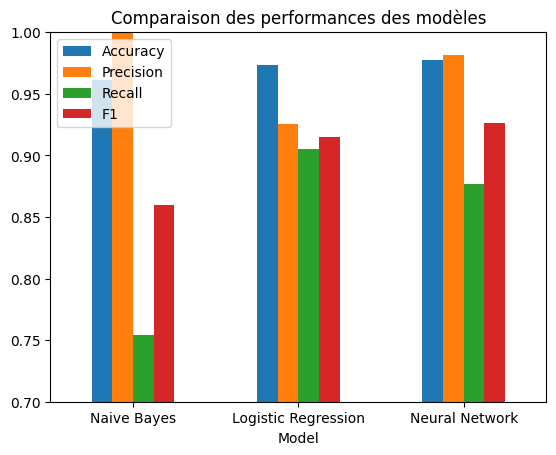

In [ ]:
results_df.set_index("Model")[["Accuracy","Precision","Recall","F1"]].plot(kind="bar")
plt.title("Comparaison des performances des modèles")
plt.xticks(rotation=0)
plt.ylim(0.7,1.0)
plt.show()

# **10) a** - PIPELINE + CROSS VALIDATION

In [ ]:

from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier

# X = TEXT RAW
X_text = df["message"]
y = df["label"]

# TF-IDF intégré dans pipeline
tfidf = TfidfVectorizer(stop_words="english", ngram_range=(1,2), min_df=2)

models = {
    "Naive Bayes": MultinomialNB(),
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Neural Network": MLPClassifier(hidden_layer_sizes=(128,64),
                                    max_iter=300,
                                    random_state=42)
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = ['accuracy','precision','recall','f1']

results = []

for name, model in models.items():

    pipeline = Pipeline([
        ("tfidf", tfidf),
        ("model", model)
    ])

    cv = cross_validate(
        pipeline,
        X_text, y,
        cv=skf,
        scoring=scoring
    )

    results.append([
        name,
        np.mean(cv['test_accuracy']),
        np.mean(cv['test_precision']),
        np.mean(cv['test_recall']),
        np.mean(cv['test_f1'])
    ])

cv_results_df = pd.DataFrame(results,
                             columns=["Model","Accuracy","Precision","Recall","F1"])

cv_results_df

,Model,Accuracy,Precision,Recall,F1
0,Naive Bayes,0.967506,1.000000,0.765484,0.867082
1,Logistic Regression,0.964471,0.984894,0.755161,0.854737
2,Neural Network,0.980360,0.953897,0.902076,0.927050


# **Test**



In [ ]:
def predict_spam(message, model):
    # Convert text → TF-IDF using the SAME vectorizer
    message_tfidf = vectorizer.transform([message])

    # Predict
    prediction = model.predict(message_tfidf)[0]

    if prediction == 1:
        return "🔴 SPAM"
    else:
        return "🟢 HAM (Not Spam)"

In [ ]:
msg1 = "Congratulations! You won a free iPhone. Click here now!"
msg2 = "Hey, are we still meeting tonight?"
msg3 = "URGENT! Your account has been suspended. Verify now!"
msg4 = "You have won $10,000 cash! Claim now."

print("Logistic Regression:")
print(predict_spam(msg1, lr_model))
print(predict_spam(msg2, lr_model))
print(predict_spam(msg3, lr_model))
print(predict_spam(msg4, lr_model))

Logistic Regression:
🗑️ SPAM
📩 HAM (Not Spam)
🗑️ SPAM
🗑️ SPAM


In [ ]:
print("Naive Bayes:")
print(predict_spam(msg1, nb_model))
print(predict_spam(msg2, nb_model))
print(predict_spam(msg3, nb_model))
print(predict_spam(msg4, nb_model))

Naive Bayes:
📩 HAM (Not Spam)
📩 HAM (Not Spam)
📩 HAM (Not Spam)
🗑️ SPAM


In [ ]:
print("Neural Network:")
print(predict_spam(msg1, mlp_model))
print(predict_spam(msg2, mlp_model))
print(predict_spam(msg3, mlp_model))
print(predict_spam(msg4, mlp_model))

Neural Network:
🗑️ SPAM
📩 HAM (Not Spam)
🗑️ SPAM
🗑️ SPAM
